## **X1**: TT - Information Lost in Feature Selection
* October 4°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 4 keeps 12 of the 67 radiomic features of Module 3, one per qubit (D-013). It walks
down the ANOVA $F$ ranking and accepts a feature only if its $|r|$ with every feature already
accepted is at most 0.95 (D-024). This notebook measures what that selection costs, in two
different senses of «information»:

1. **General information.** How much of the variation of the 67 features the 12 retain,
   without looking at the label.
2. **Label information.** How much cross-validated AUC a classifier loses with 12 features
   instead of 67, and whether the 12 chosen by $F$ do better than 12 drawn at random.

It is an **exploratory** analysis and changes nothing in the design. It uses only the
training split, with the frozen Module 4 folds (grouped by patient, D-026), and never
touches the official test set. The classifiers are classical references, a logistic
regression and a random forest on the raw features. They are not the MLP of Module 7, and
the five conditions C1–C5 are not involved. The result is recorded as H-035.

> The figure of notebook 3 (`M3_effect_sizes.png`) draws the 25 most discriminative
> features only as visual context. No step keeps 25 features: the selection goes from 67 to
> 12 directly, in Module 4.

#### **1° Setup**

**a.** Import the necessary libraries and fix the parameters

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import QuantileTransformer

warnings.filterwarnings("ignore")

SEED = 42
K = 12                                        # one feature per qubit (D-013)
R_MAX = 0.95                                  # redundancy threshold (D-024)
N_RANDOM = 20                                 # random 12-feature sets per subset
K_GRID = [1, 2, 4, 6, 8, 10, 12, 16, 20, 30]  # nested-selection curve
MODELS = ["LR", "RF"]
FINDINGS = ["mass", "calcification"]

ROOT = Path("/Users/alexander_san/TT")
M3_DIR = ROOT / "Data/processed/m3"
M4_DIR = ROOT / "Data/processed/m4"
RESULTS_DIR = ROOT / "Code/results"
FIG_DIR = ROOT / "Docs/Figures"

print("Environment:")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")

Environment:
  scikit-learn : 1.7.2
  numpy        : 2.2.6
  pandas       : 2.3.3


**b.** Load the raw features of Module 3 (training split only) and attach the frozen folds and the 12 selected features of Module 4

In [2]:
short = lambda f: f.replace("original_", "")

train, selected_m4 = {}, {}
for ft in FINDINGS:
    feats = pd.read_parquet(M3_DIR / f"features_{ft}_raw.parquet")
    folds = pd.read_parquet(M4_DIR / f"x_{ft}.parquet")[["case_id", "fold"]]
    tr = feats.merge(folds, on="case_id", validate="one_to_one")
    train[ft] = tr[tr.split == "train"].reset_index(drop=True)
    selected_m4[ft] = json.load(open(M4_DIR / f"x_{ft}.json"))["features"]

FEATURES = [c for c in train["mass"].columns if c.startswith("original_")]
assert len(FEATURES) == 67
for ft, tr in train.items():
    assert (tr.fold >= 0).all()
    print(f"{ft:13s}: {len(tr)} train lesions, {tr.patient_id.nunique()} patients, "
          f"{tr.label.mean():.1%} malignant, folds {[int(f) for f in sorted(tr.fold.unique())]}")

mass         : 1318 train lesions, 691 patients, 48.3% malignant, folds [0, 1, 2, 3, 4]
calcification: 1546 train lesions, 602 patients, 35.2% malignant, folds [0, 1, 2, 3, 4]


#### **2° Replicating the Module 4 selection**

The rule is re-implemented here so that it can be re-fitted inside each fold in section 4.
Acceptance check: fitted on the whole training split, it must return exactly the 12 features
that Module 4 stored, in the same order.

In [3]:
def select(frame, k=K, r_max=R_MAX):
    """Module 4 rule: walk down the ANOVA F ranking (ties broken by name), skip any feature
    with |r| > r_max against one already accepted, stop at k."""
    F, _ = f_classif(frame[FEATURES].values, frame.label.values)
    ranking = (pd.DataFrame({"feature": FEATURES, "F": F})
               .sort_values(["F", "feature"], ascending=[False, True]).feature)
    C = frame[FEATURES].corr().abs()
    chosen = []
    for f in ranking:
        if all(C.loc[f, s] <= r_max for s in chosen):
            chosen.append(f)
        if len(chosen) == k:
            break
    return chosen


for ft in FINDINGS:
    same = select(train[ft]) == selected_m4[ft]
    pool = len(select(train[ft], k=len(FEATURES)))
    print(f"{ft:13s}: replica reproduces Module 4 exactly: {same}; "
          f"features that survive the redundancy filter over the whole ranking: {pool} of 67")
    assert same

mass         : replica reproduces Module 4 exactly: True; features that survive the redundancy filter over the whole ranking: 39 of 67
calcification: replica reproduces Module 4 exactly: True; features that survive the redundancy filter over the whole ranking: 43 of 67


The filter cannot return more than 39 features in masses or 43 in calcifications: the rest
are near-copies of a feature ranked above them. That is the upper end of the curve in
section 4b.

#### **3° General information: how much of the 67 the 12 retain**

Each feature is mapped to a normal distribution by quantiles and standardised on train, so
that every feature weighs the same and heavy tails do not dominate. Each discarded feature
is then regressed linearly on the 12 selected ones. With $R^2_j$ the fraction of the variance
of feature $j$ explained by the 12, the fraction of the total variance the 12 retain is

$$\frac{12 + \sum_{j \notin S} R^2_j}{67}.$$

The reference is the PCA with 12 components, the best that **any** 12 linear combinations
can retain. A linear $R^2$ is a lower bound: it ignores non-linear dependence, so the
information actually retained can only be higher.

In [4]:
info_rows = []
for ft in FINDINGS:
    tr, chosen = train[ft], selected_m4[ft]
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=SEED)
    Z = pd.DataFrame(qt.fit_transform(tr[FEATURES].values), columns=FEATURES)
    Z = (Z - Z.mean()) / Z.std()
    dropped = [f for f in FEATURES if f not in chosen]
    r2 = pd.Series({f: LinearRegression().fit(Z[chosen], Z[f]).score(Z[chosen], Z[f]) for f in dropped})
    info_rows.append(dict(finding_type=ft, variance_retained_by_12=(len(chosen) + r2.sum()) / len(FEATURES),
                          variance_pca_12=PCA(n_components=K).fit(Z).explained_variance_ratio_.sum(),
                          n_dropped=len(dropped), median_r2_dropped=r2.median(),
                          dropped_r2_above_0_9=int((r2 > 0.9).sum()), dropped_r2_below_0_5=int((r2 < 0.5).sum())))
    print(f"== {ft}: the 5 discarded features the 12 recover worst (linear R^2)")
    print(r2.nsmallest(5).rename(index=short).round(3).to_string())
    print()

info_df = pd.DataFrame(info_rows)
info_df.to_csv(RESULTS_DIR / "X1_varianza_retenida.csv", index=False)
print(info_df.round(3).to_string(index=False))

== mass: the 5 discarded features the 12 recover worst (linear R^2)
glcm_ClusterShade                     0.443
firstorder_Skewness                   0.452
glrlm_HighGrayLevelRunEmphasis        0.534
glrlm_ShortRunLowGrayLevelEmphasis    0.534
firstorder_Kurtosis                   0.535



== calcification: the 5 discarded features the 12 recover worst (linear R^2)
firstorder_Kurtosis    0.556
firstorder_Maximum     0.664
firstorder_Minimum     0.669
shape2D_Sphericity     0.679
firstorder_Range       0.705

 finding_type  variance_retained_by_12  variance_pca_12  n_dropped  median_r2_dropped  dropped_r2_above_0_9  dropped_r2_below_0_5
         mass                    0.868            0.980         55              0.882                    26                     2
calcification                    0.902            0.978         55              0.911                    28                     0


#### **4° Label information: cross-validated AUC**

**a.** Five feature sets, two classifiers

Protocol: the 5 frozen folds of Module 4 (`StratifiedGroupKFold` by patient), training split
only. Every preprocessing step and every selection is fitted on the training part of each
fold, never on the held-out fold.

- **LR**: quantile transform to a normal distribution and a logistic regression with L2 and
  balanced class weights. It only sees linear effects.
- **RF**: random forest, 500 trees, at least 5 lesions per leaf, balanced class weights. It
  can use interactions between features.

Feature sets:

| Set | What it measures |
|---|---|
| all 67 | the reference without selection |
| 12 of Module 4 (fixed) | the features the circuit receives, chosen once on the whole training split |
| 12 re-selected in each fold | the same rule, refitted inside each fold: no selection leakage |
| top 12 by F, no redundancy filter | plain `SelectKBest(k=12)`, as before D-024 |
| 12 at random | mean over 20 random draws; its ± is the spread between draws, not between folds |

In [5]:
def make_model(name):
    if name == "LR":
        return make_pipeline(QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=SEED),
                             LogisticRegression(C=1.0, class_weight="balanced", max_iter=5000))
    return RandomForestClassifier(n_estimators=500, min_samples_leaf=5, class_weight="balanced",
                                  n_jobs=-1, random_state=SEED)


def cv_auc(frame, columns_for, model):
    """Mean and std of the AUC over the frozen folds, and mean number of features used.
    `columns_for` receives only the training part of each fold."""
    aucs, sizes = [], []
    for f in sorted(frame.fold.unique()):
        fit, held = frame[frame.fold != f], frame[frame.fold == f]
        cols = columns_for(fit)
        m = make_model(model).fit(fit[cols].values, fit.label.values)
        aucs.append(roc_auc_score(held.label.values, m.predict_proba(held[cols].values)[:, 1]))
        sizes.append(len(cols))
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(sizes))


rows = []
for ft in FINDINGS:
    tr = train[ft]
    rng = np.random.default_rng(SEED)
    random_sets = [list(rng.choice(FEATURES, K, replace=False)) for _ in range(N_RANDOM)]
    sets = {
        "all 67": lambda fit: FEATURES,
        "12 of Module 4 (fixed)": lambda fit, s=selected_m4[ft]: s,
        "12 re-selected in each fold": lambda fit: select(fit),
        "top 12 by F, no redundancy filter": lambda fit: select(fit, r_max=np.inf),
    }
    for model in MODELS:
        for name, fn in sets.items():
            mean, std, _ = cv_auc(tr, fn, model)
            rows.append(dict(finding_type=ft, model=model, feature_set=name, auc=mean, auc_std=std))
        rand = [cv_auc(tr, lambda fit, s=s: s, model)[0] for s in random_sets]
        rows.append(dict(finding_type=ft, model=model, feature_set=f"12 at random ({N_RANDOM} draws)",
                         auc=float(np.mean(rand)), auc_std=float(np.std(rand))))

auc_df = pd.DataFrame(rows)
auc_df.to_csv(RESULTS_DIR / "X1_auc_por_condicion.csv", index=False)

order = list(dict.fromkeys(auc_df.feature_set))
cell = auc_df.auc.map("{:.3f}".format) + " ± " + auc_df.auc_std.map("{:.3f}".format)
print(auc_df.assign(cell=cell).pivot(index=["finding_type", "feature_set"], columns="model", values="cell")
      .reindex(pd.MultiIndex.from_product([FINDINGS, order])).to_string())
print()
a = auc_df.set_index(["finding_type", "model", "feature_set"]).auc
for ft in FINDINGS:
    for model in MODELS:
        m4 = a[(ft, model, "12 of Module 4 (fixed)")]
        print(f"{ft:13s} {model}: AUC lost going from 67 to the 12 of Module 4 = {a[(ft, model, 'all 67')] - m4:.3f}; "
              f"fixed minus re-selected (selection leakage) = {m4 - a[(ft, model, '12 re-selected in each fold')]:+.3f}; "
              f"Module 4 minus random = {m4 - a[(ft, model, f'12 at random ({N_RANDOM} draws)')]:+.3f}")

model                                                       LR             RF
mass          all 67                             0.693 ± 0.039  0.695 ± 0.043
              12 of Module 4 (fixed)             0.650 ± 0.056  0.680 ± 0.046
              12 re-selected in each fold        0.653 ± 0.053  0.675 ± 0.050
              top 12 by F, no redundancy filter  0.645 ± 0.055  0.649 ± 0.034
              12 at random (20 draws)            0.656 ± 0.019  0.659 ± 0.023
calcification all 67                             0.800 ± 0.028  0.796 ± 0.018
              12 of Module 4 (fixed)             0.758 ± 0.025  0.773 ± 0.024
              12 re-selected in each fold        0.757 ± 0.024  0.774 ± 0.025
              top 12 by F, no redundancy filter  0.744 ± 0.034  0.763 ± 0.026
              12 at random (20 draws)            0.765 ± 0.015  0.775 ± 0.016

mass          LR: AUC lost going from 67 to the 12 of Module 4 = 0.042; fixed minus re-selected (selection leakage) = -0.002; Module 4 minus 

**b.** AUC as a function of the number of features

The selection rule of Module 4 is refitted inside each fold for every $k$. The point «all
non-redundant» keeps every feature that survives the filter (39 in masses, 43 in
calcifications); «all 67» drops the filter as well.

In [6]:
curve = []
for ft in FINDINGS:
    tr = train[ft]
    for model in MODELS:
        steps = [(f"top {k}", lambda fit, k=k: select(fit, k=k)) for k in K_GRID]
        steps += [("all non-redundant", lambda fit: select(fit, k=len(FEATURES))), ("all 67", lambda fit: FEATURES)]
        for name, fn in steps:
            mean, std, n = cv_auc(tr, fn, model)
            curve.append(dict(finding_type=ft, model=model, feature_set=name, n_features=n, auc=mean, auc_std=std))

curve_df = pd.DataFrame(curve)
curve_df.to_csv(RESULTS_DIR / "X1_auc_vs_k.csv", index=False)
print(curve_df.pivot_table(index=["finding_type", "n_features"], columns="model", values="auc")
      .reindex(FINDINGS, level=0).round(3).to_string())

model                        LR     RF
finding_type  n_features              
mass          1.0         0.638  0.603
              2.0         0.638  0.637
              4.0         0.650  0.635
              6.0         0.646  0.637
              8.0         0.645  0.640
              10.0        0.648  0.663
              12.0        0.653  0.675
              16.0        0.664  0.677
              20.0        0.673  0.685
              30.0        0.675  0.692
              38.6        0.677  0.697
              67.0        0.693  0.695
calcification 1.0         0.694  0.645
              2.0         0.717  0.703
              4.0         0.722  0.748
              6.0         0.737  0.770
              8.0         0.738  0.767
              10.0        0.746  0.774
              12.0        0.757  0.774
              16.0        0.760  0.773
              20.0        0.762  0.774
              30.0        0.767  0.780
              43.0        0.794  0.801
              67.0       

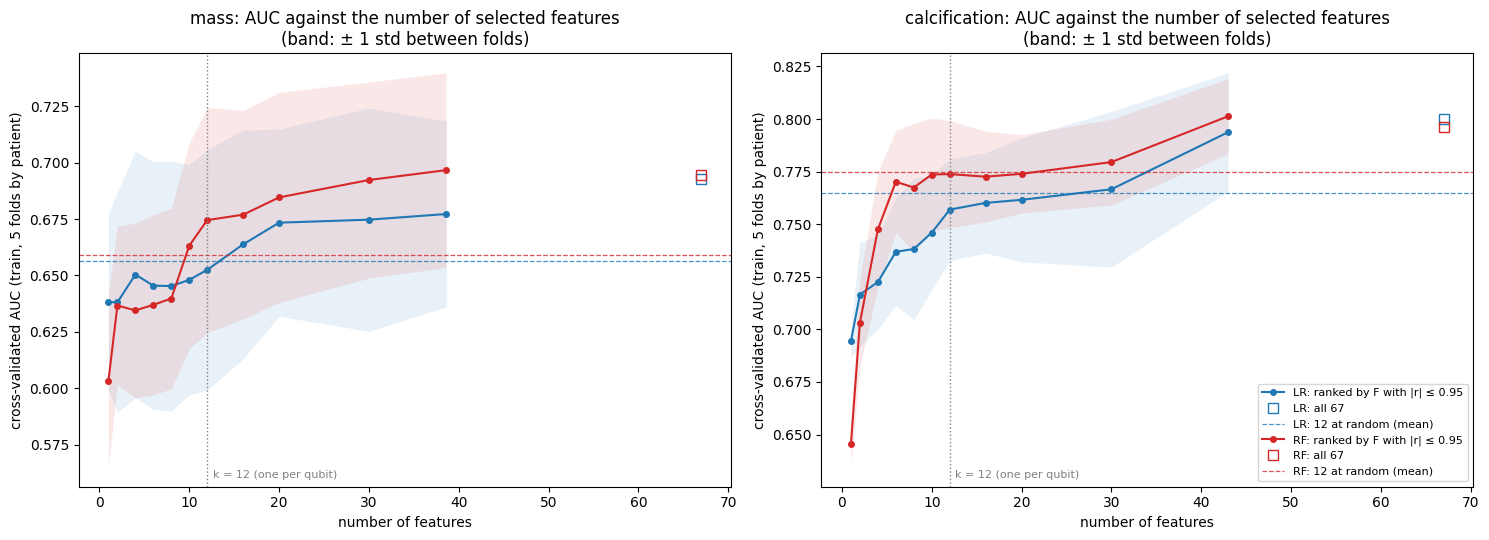

In [7]:
colors = {"LR": "C0", "RF": "C3"}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, ft in zip(axes, FINDINGS):
    for model in MODELS:
        c = curve_df[(curve_df.finding_type == ft) & (curve_df.model == model)]
        ranked, full = c[c.feature_set != "all 67"], c[c.feature_set == "all 67"].iloc[0]
        ax.plot(ranked.n_features, ranked.auc, marker="o", ms=4, color=colors[model],
                label=f"{model}: ranked by F with |r| ≤ {R_MAX}")
        ax.fill_between(ranked.n_features, ranked.auc - ranked.auc_std, ranked.auc + ranked.auc_std,
                        color=colors[model], alpha=0.10, lw=0)
        ax.plot(67, full.auc, marker="s", ms=7, mfc="none", ls="none", color=colors[model], label=f"{model}: all 67")
        rnd = a[(ft, model, f"12 at random ({N_RANDOM} draws)")]
        ax.axhline(rnd, color=colors[model], ls="--", lw=0.9, alpha=0.8, label=f"{model}: 12 at random (mean)")
    ax.axvline(K, color="gray", ls=":", lw=1)
    ax.text(K + 0.6, ax.get_ylim()[0] + 0.004, "k = 12 (one per qubit)", fontsize=8, color="gray")
    ax.set_xlabel("number of features")
    ax.set_ylabel("cross-validated AUC (train, 5 folds by patient)")
    ax.set_title(f"{ft}: AUC against the number of selected features\n(band: ± 1 std between folds)")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "X1_selection_auc_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

#### **5° Consequence**

**1. General information: little is lost.** The 12 features retain 86.8 % of the variance
of the 67 in masses and 90.2 % in calcifications, against 98 % for the best possible 12 linear
combinations. Half of the 55 discarded features are recovered at more than 90 % (26 in
masses, 28 in calcifications). Radiomic features describe a few underlying properties, mainly
size, intensity and texture, many times over. The 12 recover worst the features of the
*shape of the intensity distribution*: Skewness, Kurtosis and GLCM ClusterShade.

**2. Label information: a modest loss.** Going from 67 features to the 12 of Module 4 costs
0.042 AUC with the logistic regression in both subsets, and 0.015 (masses) and 0.023
(calcifications) with the random forest. That is about one standard deviation between folds
(0.02–0.06). The curve does not flatten at $k = 12$: the remaining signal is spread thinly
over many features, each contributing a little.

**3. The 12 chosen by $F$ do no better than 12 random features.** The differences lie within
the noise, from −0.007 to −0.002, except for the random forest in masses (+0.021). The best
individual features are not the best set. The $F$ ranking favours features that separate the
classes on their own, and those tend to measure the same property, such as a large or a
bright lesion. A random draw is more diverse, so its features complement each other.
This is the multivariate counterpart of H-030.

**4. Two checks in favour of the design.** The redundancy filter helps: the plain top 12 by
$F$ is the worst set in all four columns, which supports D-024. Selecting once on the whole
training split does not leak anything measurable: the fixed 12 and the 12 re-selected inside
each fold differ by at most 0.006 AUC, so the caveat of H-027 is small here.

**Consequences.**

- The comparison between conditions stays fair. C1–C5 all receive the same 12 features,
  so the loss affects all of them equally.
- The cost of the qubit budget, 2 to 4 AUC points with classical classifiers, is material
  for OE-6 and a limitation to declare in §7.
- The design is not changed. Switching the selection after seeing these results would add a
  degree of freedom chosen with the data in view. A multivariate selection (mRMR, L1) remains
  an optional robustness analysis, after the freeze of October 23. **Author's decision.**
- These are classical classifiers on the raw features. They bound the information available
  to every condition; they do not predict the AUC of the Module 7 MLP on C1–C5.

In [8]:
print("=" * 78)
print("X1 - INFORMATION LOST IN FEATURE SELECTION - SUMMARY")
print("=" * 78)
for ft in FINDINGS:
    i = info_df.set_index("finding_type").loc[ft]
    print(f"  {ft}")
    print(f"    variance of the 67 retained by the 12 : {i.variance_retained_by_12:.1%} (PCA-12 bound {i.variance_pca_12:.1%})")
    for model in MODELS:
        print(f"    {model}: AUC 67 -> 12 of Module 4 : {a[(ft, model, 'all 67')]:.3f} -> "
              f"{a[(ft, model, '12 of Module 4 (fixed)')]:.3f};  12 at random {a[(ft, model, f'12 at random ({N_RANDOM} draws)')]:.3f};"
              f"  top 12 without filter {a[(ft, model, 'top 12 by F, no redundancy filter')]:.3f}")
print("  Train only, frozen folds by patient; test untouched. Recorded as H-035.")
print("=" * 78)

X1 - INFORMATION LOST IN FEATURE SELECTION - SUMMARY
  mass
    variance of the 67 retained by the 12 : 86.8% (PCA-12 bound 98.0%)
    LR: AUC 67 -> 12 of Module 4 : 0.693 -> 0.650;  12 at random 0.656;  top 12 without filter 0.645
    RF: AUC 67 -> 12 of Module 4 : 0.695 -> 0.680;  12 at random 0.659;  top 12 without filter 0.649
  calcification
    variance of the 67 retained by the 12 : 90.2% (PCA-12 bound 97.8%)
    LR: AUC 67 -> 12 of Module 4 : 0.800 -> 0.758;  12 at random 0.765;  top 12 without filter 0.744
    RF: AUC 67 -> 12 of Module 4 : 0.796 -> 0.773;  12 at random 0.775;  top 12 without filter 0.763
  Train only, frozen folds by patient; test untouched. Recorded as H-035.
